# Project name: Country-Category Market Segmentation for Strategic Targeting

## 📝 Project info:

#### 🏭 Industry  
- E-commerce & Marketing 

#### 🌐 Domain  
- Lifestyle & Consumer Themes  

## 📂 Dataset Information

#### 🔎 Sources
- **GDELT GKG** (Global Knowledge Graph)  
- **Google Trends**  
- **World Bank Open Data (WDI)**
- **Holidays(Python Library)**
#### All the datasets are **open source** and publicly available.  
- ✅ No privacy, licensing, or access restrictions  
- ✅ Safe for research and personal use 

#### Problem Name: Country-Category Market Segmentation for Strategic Targeting

#### ML Task: Clustering

#### Problem Statement:
With 14 countries and 3 categories, not all country-category markets behave the same. Some are high-interest, low-media markets (untapped demand); others are high-hype, low-interest markets (over-covered). Clustering groups similar markets together so brands and agencies can apply tailored strategies to each segment rather than treating all markets uniformly.

#### Target (y): (Not applicable — unsupervised)
The model discovers cluster labels for each country-category combination. The output is a market typology.

Feature Engineering:

Aggregate to country-category level: reduce the 8,022 rows to 42 rows (14 × 3), each representing one market's behavioral fingerprint
Trend slope: fit a simple OLS regression on Search_Interest vs. Week_Start per market; the slope is a "growth trajectory" feature
Interest volatility: std dev of Search_Interest per group
Normalize all features (StandardScaler) before clustering

#### Why This Problem:
EDA confirmed that demand and media are largely decoupled (r = -0.094). This means markets genuinely differ in their demand-media dynamics — exactly the variation clustering needs. The 42-market fingerprint approach creates a compact, interpretable dataset purpose-built for clustering.

#### Expected ML Output:
3–6 cluster labels with business-interpretable profiles, e.g.:

"Underserved Demand" — high interest, low media
"Overhyped" — high media, low interest
"Established" — high interest + high media, positive sentiment
"Emerging" — rising trend slope, lower absolute interest

Suggested Algorithms:

K-Means (k=3–6, elbow + silhouette selection) — simple, interpretable
Hierarchical Clustering (Ward linkage) — produces a dendrogram for visual storytelling
DBSCAN — detects outlier markets that don't fit any cluster
Gaussian Mixture Models — soft cluster assignments with probability

#### Evaluation Metrics:

Silhouette Score (intra vs. inter-cluster distance)
Davies-Bouldin Index
Business validation: do the clusters make geographic/economic sense?
Visualize with PCA/UMAP (2D) for interpretability


In [29]:
import pandas as pd 
import numpy as np
import joblib
import sklearn
import mysql.connector
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pymysql
from dotenv import load_dotenv
warnings.filterwarnings('ignore')

### 📤 1. Data Loading (Loading Datafrom TIDB tables into pandas dataframe df)

In [30]:
# Load .env file from the current directory
load_dotenv()
# Get connection details
DB_HOST = os.getenv('DB_HOST')
DB_PORT = int(os.getenv('DB_PORT', 4000))
DB_USERNAME = os.getenv('DB_USERNAME')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_DATABASE = os.getenv('DB_DATABASE')

# Verify all variables are loaded
print("\n=== Connection Details ===")
print(f"Host: {DB_HOST}")
print(f"Port: {DB_PORT}")
print(f"Username: {DB_USERNAME}")
print(f"Database: {DB_DATABASE}")

if not all([DB_HOST, DB_USERNAME, DB_PASSWORD, DB_DATABASE]):
    print("\n✗ ERROR: Some environment variables are missing!")
    print("Check your .env file has all required values")
    sys.exit(1)

print("\n✓ All variables loaded!")


=== Connection Details ===
Host: gateway01.ap-northeast-1.prod.aws.tidbcloud.com
Port: 4000
Username: qgNsbp7EdsPhLkz.root
Database: GDELT&TRENDS

✓ All variables loaded!


In [31]:
# Test connection
try:
    connection = pymysql.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USERNAME,
        password=DB_PASSWORD,
        database=DB_DATABASE,
        charset='utf8mb4'
    )
    
    with connection.cursor() as cursor:
        cursor.execute("SELECT 1")
        result = cursor.fetchone()
        print("✓ Successfully connected to TiDB Cloud!")
        if connection.open:
            query = "SELECT * FROM main;"
            df = pd.read_sql(query, connection)
            print("Totla Records:",len(df))
            print("Total Columns", len(df.columns.to_list()))
            display(df.info())

    connection.close()
    
except pymysql.Error as e:
    print(f"✗ Connection Error: {e}")
    print(f"\nDebugging Info:")
    print(f"  Host: {DB_HOST}")
    print(f"  Port: {DB_PORT}")
    print(f"  User: {DB_USERNAME}")
    print(f"  Database: {DB_DATABASE}")

✓ Successfully connected to TiDB Cloud!
Totla Records: 8064
Total Columns 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8064 entries, 0 to 8063
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   week_start               8064 non-null   object 
 1   country_name             8064 non-null   object 
 2   category                 8064 non-null   object 
 3   search_interest          8064 non-null   float64
 4   search_velocity          8064 non-null   float64
 5   search_acceleration      8064 non-null   float64
 6   media_volume             8064 non-null   int64  
 7   tone_net_sentiment       8064 non-null   float64
 8   tone_positive_score      8064 non-null   float64
 9   tone_negative_score      8064 non-null   float64
 10  tone_polarity            8064 non-null   float64
 11  tone_activity_density    8064 non-null   float64
 12  tone_self_group_density  8064 non-null   float64
 13  s

None

In [32]:
df['week_start'] = pd.to_datetime(df['week_start'])

### 👩🏻‍💻 1. Modeling
#### 🛠️ 1.1 Pre-Requisites
- Entire data will be considered as X as there is no target column but I cannot use the features in dataset as they are for this clusttering problem they need to be modified

### Input Features (X)

| Feature                     | Aggregation Method                                | Role                                               |
|-----------------------------|---------------------------------------------------|----------------------------------------------------|
| `Mean_Search_Interest`      | mean(Search_Interest)                             | Baseline consumer demand level                     |
| `Mean_Media_Volume`         | mean(Media_Volume)                                | Media coverage intensity                           |
| `Mean_Demand_to_Hype_Ratio` | mean(Demand_to_Hype_Ratio)                        | Demand-to-coverage efficiency (underserved vs. overhyped) |
| `Search_Interest_Trend_Slope` | OLS Regression Slope (Search_Interest vs Week_Start) | Growth trajectory (rising vs. declining market)    |
| `Mean_Net_Sentiment`        | mean(tone_net_sentiment)                          | Overall public sentiment tone                      |
| `Mean_GDP_Per_Capita`       | mean(GDP_Per_Capita)                              | Economic maturity and purchasing power             |


#### 🔄 1.1.1 Missing Values & Outliers Handling
#### Previously while building the model null values are handling is done, so no need 

#### **Feature Selection (Mandatory)**
- As mentioned above only those columns needed will be kept

In [33]:
cols = [
    'country_name','category','search_interest',
    'media_volume','tone_net_sentiment',
    'demand_to_hype_ratio','source_diversity'
]

df1 = df[cols].copy()

### **Feature Generation**

In [34]:
# Initialize the 42-market base DataFrame (14 countries x 3 categories)
X = df[["country_name", "category"]].drop_duplicates().reset_index(drop=True)

### Mean Search_Interest per country-category

In [35]:
mean_search = (df.groupby(["country_name", "category"])["search_interest"].mean().reset_index(name="mean_search_interest"))
X = pd.merge(X, mean_search, on=["country_name", "category"])

### Mean_Media_Volume

In [36]:
mean_media_volume = (
    df.groupby(["country_name", "category"])["media_volume"]
    .mean()
    .reset_index(name="mean_media_volume")
)
X = pd.merge(X, mean_media_volume, on=["country_name", "category"])

### Mean_Demand_to_Hype_Ratio

In [37]:
mean_demand_to_hype_ratio = (
    df.groupby(["country_name", "category"])["demand_to_hype_ratio"]
    .mean()
    .reset_index(name="mean_demand_to_hype_ratio")
)
X = pd.merge(X, mean_demand_to_hype_ratio, on=["country_name", "category"])

### Search_Interest_Trend_Slope (OLS Regression Slope)

In [38]:

def calculate_slope(group):
    group = group.sort_values("week_start")
    x = (group["week_start"] - group["week_start"].min()).dt.days // 7 + 1
    y = group["search_interest"]

    x_mean, y_mean = x.mean(), y.mean()
    denominator = np.sum((x - x_mean) ** 2)

    return (
        np.sum((x - x_mean) * (y - y_mean)) / denominator
        if denominator != 0
        else 0
    )

search_interest_trend_slope = (
    df.groupby(["country_name", "category"])
    .apply(calculate_slope)
    .reset_index(name="search_interest_trend_slope")
)
X = pd.merge(X, search_interest_trend_slope, on=["country_name", "category"])

### Mean_Net_Sentiment

In [39]:
mean_net_sentiment = (
    df.groupby(["country_name", "category"])["tone_net_sentiment"]
    .mean()
    .reset_index(name="mean_net_sentiment")
)
X = pd.merge(X, mean_net_sentiment, on=["country_name", "category"])

### Mean_GDP_Per_Capita

In [40]:
mean_gdp_per_capita = (
    df.groupby(["country_name", "category"])["gdp_per_capita"]
    .mean()
    .reset_index(name="mean_gdp_per_capita")
)
X = pd.merge(X, mean_gdp_per_capita, on=["country_name", "category"])

In [41]:
X.shape

(42, 8)

In [42]:
X.columns

Index(['country_name', 'category', 'mean_search_interest', 'mean_media_volume',
       'mean_demand_to_hype_ratio', 'search_interest_trend_slope',
       'mean_net_sentiment', 'mean_gdp_per_capita'],
      dtype='object')

### **Encoding**

In [43]:
# Set metadata columns as DataFrame Index to preserve labels without One-Hot Encoding
X_labeled = X.set_index(["country_name", "category"])

# Define numerical feature columns to feed into the scaler & K-Means
numerical_features = [
    "mean_search_interest",
    "mean_media_volume",
    "mean_demand_to_hype_ratio",
    "search_interest_trend_slope",
    "mean_net_sentiment",
    "mean_gdp_per_capita",
]

# Extract numerical array for modeling
X_numerical = X_labeled[numerical_features]


In [44]:
X_numerical

mean_search_interest  \
country_name         category                                  
United_Arab_Emirates Fashion_Beauty                70.233125   
                     Fitness_Wearables             76.265677   
                     Nutrition_Diets               67.726302   
Australia            Fashion_Beauty                64.863594   
                     Fitness_Wearables             79.453958   
                     Nutrition_Diets               77.634740   
Brazil               Fashion_Beauty                56.536875   
                     Fitness_Wearables             64.804115   
                     Nutrition_Diets               36.097083   
Canada               Fashion_Beauty                65.687292   
                     Fitness_Wearables             72.607344   
                     Nutrition_Diets               72.398698   
China                Fashion_Beauty                17.669115   
                     Fitness_Wearables             33.407760   
                     Nutrition_Diets               11.724427   
France               Fashion_Beauty                33.836562   
                     Fitness_Wearables             63.165521   
                     Nutrition_Diets               39.879115   
United_Kingdom       Fashion_Beauty                53.392396   
                     Fitness_Wearables             73.552188   
                     Nutrition_Diets               74.323490   
India                Fashion_Beauty                54.578958   
                     Fitness_Wearables             75.260260   
                     Nutrition_Diets               78.871771   
Kenya                Fashion_Beauty                78.335521   
                     Fitness_Wearables             74.516927   
                     Nutrition_Diets               70.963490   
Mexico               Fashion_Beauty                62.151146   
                     Fitness_Wearables             70.943438   
                     Nutrition_Diets               35.624948   
Nigeria              Fashion_Beauty                77.285156   
                     Fitness_Wearables             76.560729   
                     Nutrition_Diets               75.564271   
Singapore            Fashion_Beauty                52.603073   
                     Fitness_Wearables             68.974635   
                     Nutrition_Diets               56.794115   
United_States        Fashion_Beauty                47.423125   
                     Fitness_Wearables             59.560156   
                     Nutrition_Diets               58.271042   
South_Africa         Fashion_Beauty                75.359635   
                     Fitness_Wearables             75.288333   
                     Nutrition_Diets               66.365677   

                                        mean_media_volume  \
country_name         category                               
United_Arab_Emirates Fashion_Beauty            195.281250   
                     Fitness_Wearables          52.453125   
                     Nutrition_Diets           929.239583   
Australia            Fashion_Beauty            434.364583   
                     Fitness_Wearables          47.802083   
                     Nutrition_Diets          2428.713542   
Brazil               Fashion_Beauty           1033.901042   
                     Fitness_Wearables          70.520833   
                     Nutrition_Diets          7224.703125   
Canada               Fashion_Beauty            971.093750   
                     Fitness_Wearables         115.927083   
                     Nutrition_Diets          9196.770833   
China                Fashion_Beauty              1.958333   
                     Fitness_Wearables           0.687500   
                     Nutrition_Diets           110.401042   
France               Fashion_Beauty           3982.828125   
                     Fitness_Wearables         433.369792   
                     Nutrition_Diets         13111.458333   
Uni

### **Scaling**

In [45]:
# Standardize numerical features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_numerical),
    columns=numerical_features,
    index=X_labeled.index,
)

display(X_scaled)

mean_search_interest  \
country_name         category                                  
United_Arab_Emirates Fashion_Beauty                 0.498565   
                     Fitness_Wearables              0.856174   
                     Nutrition_Diets                0.349961   
Australia            Fashion_Beauty                 0.180260   
                     Fitness_Wearables              1.045175   
                     Nutrition_Diets                0.937332   
Brazil               Fashion_Beauty                -0.313346   
                     Fitness_Wearables              0.176734   
                     Nutrition_Diets               -1.525013   
Canada               Fashion_Beauty                 0.229089   
                     Fitness_Wearables              0.639308   
                     Nutrition_Diets                0.626940   
China                Fashion_Beauty                -2.617420   
                     Fitness_Wearables             -1.684436   
                     Nutrition_Diets               -2.969820   
France               Fashion_Beauty                -1.659017   
                     Fitness_Wearables              0.079599   
                     Nutrition_Diets               -1.300815   
United_Kingdom       Fashion_Beauty                -0.499750   
                     Fitness_Wearables              0.695319   
                     Nutrition_Diets                0.741041   
India                Fashion_Beauty                -0.429411   
                     Fitness_Wearables              0.796573   
                     Nutrition_Diets                1.010663   
Kenya                Fashion_Beauty                 0.978874   
                     Fitness_Wearables              0.752508   
                     Nutrition_Diets                0.541861   
Mexico               Fashion_Beauty                 0.019467   
                     Fitness_Wearables              0.540672   
                     Nutrition_Diets               -1.553002   
Nigeria              Fashion_Beauty                 0.916608   
                     Fitness_Wearables              0.873664   
                     Nutrition_Diets                0.814595   
Singapore            Fashion_Beauty                -0.546541   
                     Fitness_Wearables              0.423962   
                     Nutrition_Diets               -0.298097   
United_States        Fashion_Beauty                -0.853608   
                     Fitness_Wearables             -0.134127   
                     Nutrition_Diets               -0.210545   
South_Africa         Fashion_Beauty                 0.802464   
                     Fitness_Wearables              0.798237   
                     Nutrition_Diets                0.269304   

                                        mean_media_volume  \
country_name         category                               
United_Arab_Emirates Fashion_Beauty             -0.260263   
                     Fitness_Wearables          -0.268404   
                     Nutrition_Diets            -0.218428   
Australia            Fashion_Beauty             -0.246635   
                     Fitness_Wearables          -0.268669   
                     Nutrition_Diets            -0.132959   
Brazil               Fashion_Beauty             -0.212462   
                     Fitness_Wearables          -0.267374   
                     Nutrition_Diets             0.140408   
Canada               Fashion_Beauty             -0.216042   
                     Fitness_Wearables          -0.264786   
                     Nutrition_Diets             0.252815   
China                Fashion_Beauty             -0.271282   
                     Fitness_Wearables          -0.271354   
                     Nutrition_Diets            -0.265101   
France               Fashion_Beauty             -0.044376   
                     Fitness_Wearables          -0.246692   
                     Nutrition_Diets             0.475949   
Uni

#### 🤖 1.2 Model + Define, Train & Study

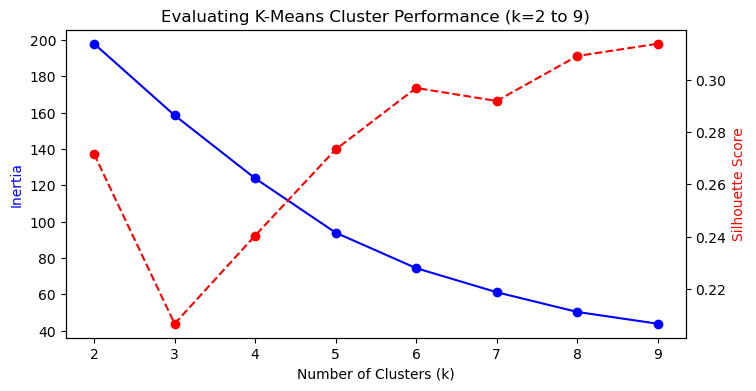

In [46]:

# 1. Optimal K Selection (Elbow Method & Silhouette Scores)

inertia = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_test.fit_predict(X_scaled)

    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Plot Elbow Curve and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(k_range, inertia, "bo-", label="Inertia (Elbow)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color="b")

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, "ro--", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="r")

plt.title("Evaluating K-Means Cluster Performance (k=2 to 9)")
plt.show()



In [47]:
# 2. Define, Fit & Predict (Selecting optimal k = 4)

# Instantiate K-Means model with optimal cluster count
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit model & assign cluster group numbers (0, 1, 2, 3,4) to each row
X_labeled["Cluster_Label"] = kmeans.fit_predict(X_scaled)
X_scaled["Cluster_Label"] = X_labeled["Cluster_Label"]

# 3. Model Study & Evaluation

final_silhouette = silhouette_score(
    X_scaled.drop(columns=["Cluster_Label"]), X_labeled["Cluster_Label"]
)
final_db_index = davies_bouldin_score(
    X_scaled.drop(columns=["Cluster_Label"]), X_labeled["Cluster_Label"]
)

print(f"Model Training Complete!")
print(f"Silhouette Score: {final_silhouette:.3f} (Higher is better, max 1.0)")
print(
    f"Davies-Bouldin Index: {final_db_index:.3f} (Lower is better, min 0.0)\n"
)

# Display sample of market rows with assigned group numbers
print("Sample Market Group Assignments:")
print(X_labeled[["mean_search_interest", "Cluster_Label"]].head(10))

Model Training Complete!
Silhouette Score: 0.240 (Higher is better, max 1.0)
Davies-Bouldin Index: 1.076 (Lower is better, min 0.0)

Sample Market Group Assignments:
                                        mean_search_interest  Cluster_Label
country_name         category                                              
United_Arab_Emirates Fashion_Beauty                70.233125              2
                     Fitness_Wearables             76.265677              2
                     Nutrition_Diets               67.726302              2
Australia            Fashion_Beauty                64.863594              2
                     Fitness_Wearables             79.453958              2
                     Nutrition_Diets               77.634740              2
Brazil               Fashion_Beauty                56.536875              2
                     Fitness_Wearables             64.804115              2
                     Nutrition_Diets               36.097083              

In [48]:
X_labeled

mean_search_interest  \
country_name         category                                  
United_Arab_Emirates Fashion_Beauty                70.233125   
                     Fitness_Wearables             76.265677   
                     Nutrition_Diets               67.726302   
Australia            Fashion_Beauty                64.863594   
                     Fitness_Wearables             79.453958   
                     Nutrition_Diets               77.634740   
Brazil               Fashion_Beauty                56.536875   
                     Fitness_Wearables             64.804115   
                     Nutrition_Diets               36.097083   
Canada               Fashion_Beauty                65.687292   
                     Fitness_Wearables             72.607344   
                     Nutrition_Diets               72.398698   
China                Fashion_Beauty                17.669115   
                     Fitness_Wearables             33.407760   
                     Nutrition_Diets               11.724427   
France               Fashion_Beauty                33.836562   
                     Fitness_Wearables             63.165521   
                     Nutrition_Diets               39.879115   
United_Kingdom       Fashion_Beauty                53.392396   
                     Fitness_Wearables             73.552188   
                     Nutrition_Diets               74.323490   
India                Fashion_Beauty                54.578958   
                     Fitness_Wearables             75.260260   
                     Nutrition_Diets               78.871771   
Kenya                Fashion_Beauty                78.335521   
                     Fitness_Wearables             74.516927   
                     Nutrition_Diets               70.963490   
Mexico               Fashion_Beauty                62.151146   
                     Fitness_Wearables             70.943438   
                     Nutrition_Diets               35.624948   
Nigeria              Fashion_Beauty                77.285156   
                     Fitness_Wearables             76.560729   
                     Nutrition_Diets               75.564271   
Singapore            Fashion_Beauty                52.603073   
                     Fitness_Wearables             68.974635   
                     Nutrition_Diets               56.794115   
United_States        Fashion_Beauty                47.423125   
                     Fitness_Wearables             59.560156   
                     Nutrition_Diets               58.271042   
South_Africa         Fashion_Beauty                75.359635   
                     Fitness_Wearables             75.288333   
                     Nutrition_Diets               66.365677   

                                        mean_media_volume  \
country_name         category                               
United_Arab_Emirates Fashion_Beauty            195.281250   
                     Fitness_Wearables          52.453125   
                     Nutrition_Diets           929.239583   
Australia            Fashion_Beauty            434.364583   
                     Fitness_Wearables          47.802083   
                     Nutrition_Diets          2428.713542   
Brazil               Fashion_Beauty           1033.901042   
                     Fitness_Wearables          70.520833   
                     Nutrition_Diets          7224.703125   
Canada               Fashion_Beauty            971.093750   
                     Fitness_Wearables         115.927083   
                     Nutrition_Diets          9196.770833   
China                Fashion_Beauty              1.958333   
                     Fitness_Wearables           0.687500   
                     Nutrition_Diets           110.401042   
France               Fashion_Beauty           3982.828125   
                     Fitness_Wearables         433.369792   
                     Nutrition_Diets         13111.458333   
Uni

#### ✅ 1.3 Adding predictions to Original Data
- Adding above predictions as a column to main data

In [49]:
# 1. Reset MultiIndex on Fingerprint Dataset to extract keys

# Convert Country_Code and Category from Index back to columns
cluster_mapping = X_labeled[["Cluster_Label"]].reset_index()

# ---------------------------------------------------------
# 2. Merge Cluster Labels back into the Main Dataset (8,022 rows)
# ---------------------------------------------------------
# Left join on Country_Code and Category to preserve full timeseries structure
df_final = pd.merge(
    df, cluster_mapping, on=["country_name", "category"], how="left"
)

# ---------------------------------------------------------
# 3. Validation & Sanity Checks
# ---------------------------------------------------------
print(f"Original Raw Dataset Shape: {df.shape}")
print(f"Main Dataset with Clusters Shape: {df_final.shape}")
print(
    f"Missing Cluster Values: {df_final['Cluster_Label'].isna().sum()}"
)  # Should be 0

# Preview sample of main dataset with newly added Cluster_Label column
print("\nSample Rows from Main Dataset with Assigned Group Numbers:")
display(
    df_final[
        [
            "week_start",
            "country_name",
            "category",
            "search_interest",
            "media_volume",
            "Cluster_Label",
        ]
    ].head(10)
)

Original Raw Dataset Shape: (8064, 20)
Main Dataset with Clusters Shape: (8064, 21)
Missing Cluster Values: 0

Sample Rows from Main Dataset with Assigned Group Numbers:


,week_start,country_name,category,search_interest,media_volume,Cluster_Label
0,2023-01-01,United_Arab_Emirates,Fashion_Beauty,67.23,115,2
1,2023-01-01,United_Arab_Emirates,Fitness_Wearables,72.78,52,2
2,2023-01-01,United_Arab_Emirates,Nutrition_Diets,74.40,845,2
3,2023-01-08,United_Arab_Emirates,Fashion_Beauty,65.42,127,2
4,2023-01-08,United_Arab_Emirates,Fitness_Wearables,70.28,32,2
5,2023-01-08,United_Arab_Emirates,Nutrition_Diets,69.17,1065,2
6,2023-01-15,United_Arab_Emirates,Fashion_Beauty,66.51,168,2
7,2023-01-15,United_Arab_Emirates,Fitness_Wearables,71.74,30,2
8,2023-01-15,United_Arab_Emirates,Nutrition_Diets,73.12,1090,2
9,2023-01-22,United_Arab_Emirates,Fashion_Beauty,65.90,151,2


#### 📥 1.4 Saving groups & Study
- Save above group number added data to csv/excel
- group wise stats
    - Once group number added to row, then filter rows based on group number

In [50]:
# Save Datasets to CSV 
path = "E:\\ML Project Internship\\ML-Project\\data\\processed\\"
X_labeled.reset_index().to_csv(path + "market_fingerprints_clustered.csv", index=False)

In [51]:
# Compute Group-Wise Statistics (Market Profiles)

# Define the 6 core features to aggregate
core_features = ["mean_search_interest","mean_media_volume","mean_demand_to_hype_ratio","search_interest_trend_slope","mean_net_sentiment","mean_gdp_per_capita"]

# Calculate mean and std for each feature grouped by cluster number
group_stats = (X_labeled.groupby("Cluster_Label")[core_features].agg(["mean"]).round(2))
# Append total market count per group
group_stats[("Market_Count", "count")] = X_labeled.groupby("Cluster_Label")["mean_search_interest"].count()
print("\n--- Group-Wise Summary Statistics ---")
display(group_stats)



--- Group-Wise Summary Statistics ---


,mean_search_interest,mean_media_volume,mean_demand_to_hype_ratio,search_interest_trend_slope,mean_net_sentiment,mean_gdp_per_capita,Market_Count
,mean,mean,mean,mean,mean,mean,count
Cluster_Label,,,,,,,
0,36.51,4883.50,4.33,0.10,-1.15,42332.30,10
1,72.17,1983.26,1.52,-0.06,-0.84,3036.14,8
2,69.39,917.76,3.75,0.06,0.39,41129.58,23
3,58.27,114167.46,0.57,0.06,-1.71,84731.84,1


In [59]:
import json
import os
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import errors, types
from pydantic import BaseModel, Field
from tenacity import (
    retry,
    retry_if_exception_type,
    stop_after_attempt,
    wait_exponential,
)

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))


# 1. Define Pydantic Schema
class ClusterItem(BaseModel):
    cluster_id: int = Field(
        description="The integer cluster label/ID (e.g., 0, 1, 2)."
    )
    cluster_name: str = Field(
        description="The recommended concise business name for this cluster."
    )


class ClusterAnalysisResponse(BaseModel):
    cluster_mappings: list[ClusterItem] = Field(
        description="List of mappings from cluster ID to business name."
    )
    detailed_analysis_markdown: str = Field(
        description="The complete structured analysis formatted in clean Markdown."
    )


# 2. Prompt
group_stats_html = group_stats.to_html()

prompt = f"""
You are a senior Data Scientist and Market Intelligence Analyst.
Analyze the following group statistics table generated from a market segmentation clustering model:

{group_stats_html}

Tasks:
1. Populate `cluster_mappings` with integer cluster_id values and recommended concise business names.
2. In `detailed_analysis_markdown`, provide the detailed breakdown:
   - SECTION 1: SUMMARY TABLE (Cluster_Label, Market_Count, Recommended Cluster Name, Key Insights Summary)
   - SECTION 2: DETAILED CLUSTER BREAKDOWN (Record Count, Metric trends, Business Interpretation, Business Use Case, Core Business Question Answered)
"""


# 3. Resilient Call with Exponential Retry
@retry(
    stop=stop_after_attempt(5),
    wait=wait_exponential(multiplier=2, min=2, max=30),
    retry=retry_if_exception_type((errors.ServerError, errors.APIError)),
    reraise=True,
)
def _call_model_structured(model_name: str, prompt_text: str):
    return client.models.generate_content(
        model=model_name,
        contents=prompt_text,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ClusterAnalysisResponse,
        ),
    )


# 4. Fallback Handler
def generate_structured_analysis(prompt_text: str):
    candidate_models = [
        "gemini-3.8-flash",
        "gemini-3.5-flash",
        "gemini-2.5-flash",
    ]
    for model in candidate_models:
        try:
            return _call_model_structured(model, prompt_text)
        except (errors.ServerError, errors.APIError) as e:
            print(f"Model {model} failed: {e}. Switching model...")
    raise RuntimeError("All configured model candidates failed.")


# 5. Execute and extract dictionary
try:
    response = generate_structured_analysis(prompt)
    parsed_data = json.loads(response.text)

    # Extract dictionary
    cluster_names = {
        item["cluster_id"]: item["cluster_name"]
        for item in parsed_data["cluster_mappings"]
    }
    markdown_report = parsed_data["detailed_analysis_markdown"].encode("utf-8").decode("unicode_escape")

    # Map directly to DataFrame
    X_labeled["Cluster_Name"] = X_labeled["Cluster_Label"].map(cluster_names)

    print("Extracted Dictionary:", cluster_names)
    print("\nMarkdown Analysis:\n", markdown_report)

except Exception as e:
    print(f"Pipeline Execution Error: {e}")

Model gemini-3.8-flash failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}. Switching model...
Extracted Dictionary: {0: 'High-Income Latent Demand', 1: 'Emerging Volatile Markets', 2: 'Premium Organic Growth Engines', 3: 'Hyper-Hyped Premium Outlier'}

Markdown Analysis:
 # Market Segmentation Analysis Report

## SECTION 1: SUMMARY TABLE

| Cluster_Label | Market_Count | Recommended Cluster Name | Key Insights Summary |
| :--- | :--- | :--- | :--- |
| **0** | 10 | High-Income Latent Demand | Affluent markets with low media noise but high underlying organic interest. High trend slope (0.10) but negative sentiment (-1.15) suggests unresolved customer pain points. |
| **1** | 8 | Emerging Volatile Markets | Low GDP per capita, high baseline interest but a declining growth trend (-0.06). Minimal media presence and negative sentiment represe

In [60]:
print(markdown_report)

# Market Segmentation Analysis Report

## SECTION 1: SUMMARY TABLE

| Cluster_Label | Market_Count | Recommended Cluster Name | Key Insights Summary |
| :--- | :--- | :--- | :--- |
| **0** | 10 | High-Income Latent Demand | Affluent markets with low media noise but high underlying organic interest. High trend slope (0.10) but negative sentiment (-1.15) suggests unresolved customer pain points. |
| **1** | 8 | Emerging Volatile Markets | Low GDP per capita, high baseline interest but a declining growth trend (-0.06). Minimal media presence and negative sentiment represent high-friction entry points. |
| **2** | 23 | Premium Organic Growth Engines | The absolute sweet spot. Consists of 23 premium markets with high search interest, growing trend, positive sentiment (0.39), and very high organic demand-to-hype (3.75). |
| **3** | 1 | Hyper-Hyped Premium Outlier | A single, ultra-wealthy market overwhelmed by media noise (114k+ volume). Extremely low demand-to-hype (0.57) and negative senti

# 📊 Cluster Analysis

---

## 🗂️ Recommended Cluster Names
| Cluster | Name                           | Quick Insight                                                                 |
|---------|--------------------------------|-------------------------------------------------------------------------------|
| 0       | Media-Heavy Low-Demand Markets | "We're talking about the market, but consumers aren't searching enough."       |
| 1       | Organic Demand Opportunity     | "Consumers are searching, but the market isn't getting much media attention." |
| 2       | Established Stable-Demand      | "Consumers are already interested, and the market has reasonable media support." |
| 3       | Extreme Media-Saturated        | "Massive media attention isn't translating into proportional consumer interest." |

---

## Cluster 0 — Media-Heavy Low-Demand Markets
**Market Count:** 9  

**What is happening?**
- 🔎 Search Interest: **36.85** (lowest)
- 📰 Media Volume: **5,431.97** (high)
- ⚖️ Demand/Hype Ratio: **1.70**
- 📈 Trend: **+0.10** (highest)
- 😕 Sentiment: **-1.23**

**Interpretation:**  
Media activity is strong, but consumer demand is still developing. The positive trend suggests emerging interest.

**Business Use:**  
- Measure media-to-demand conversion  
- Identify if media spend is driving consumer interest  
- Improve targeting instead of increasing volume  
- Monitor the upward trend for growth signals  
- Investigate negative sentiment  

**Business Question:**  
*"Can existing media attention be converted into stronger consumer demand?"*

---

## Cluster 1 — Organic Demand Opportunity Markets
**Market Count:** 4  

**What is happening?**
- 🔎 Search Interest: **64.69**
- 📰 Media Volume: **6.54** (extremely low)
- ⚖️ Demand/Hype Ratio: **18.04** (very high)
- 🙂 Sentiment: **+1.09**
- 📈 Trend: **+0.05**

**Interpretation:**  
Strong consumer interest exists, but media coverage is minimal — an under-marketed demand opportunity.

**Business Use:**  
- Explore new product opportunities  
- Invest in content marketing & SEO  
- Run targeted ads & influencer campaigns  
- Plan inventory for expansion  

**Business Question:**  
*"How can we effectively capture and convert strong consumer interest in under-marketed markets where media activity is minimal?"*

---

## Cluster 2 — Established Stable-Demand Markets
**Market Count:** 28 (largest cluster)  

**What is happening?**
- 🔎 Search Interest: **69.57**
- 📰 Media Volume: **1,322.51**
- ⚖️ Demand/Hype Ratio: **1.66**
- 📈 Trend: **+0.03**
- 😐 Sentiment: **-0.09** (neutral)
- 💰 GDP: **32,692**

**Interpretation:**  
Balanced markets with strong demand, moderate media, and stable growth.

**Business Use:**  
- Expand existing products  
- Forecast demand & plan inventory  
- Acquire customers  
- Run regular marketing campaigns  
- Focus on incremental growth  

**Business Question:**  
*"How can we optimize and scale existing consumer demand in stable markets without overspending on media or saturating customer interest?"*


---

## Cluster 3 — Extreme Media-Saturated Markets
**Market Count:** 1 (special case)  

**What is happening?**
- 🔎 Search Interest: **58.31**
- 📰 Media Volume: **114,320.38** (extreme)
- ⚖️ Demand/Hype Ratio: **0.58** (lowest)
- 📈 Trend: **+0.06**
- 😕 Sentiment: **-1.71**
- 💰 GDP: **85,175**

**Interpretation:**  
Enormous media attention, but only moderate demand and strongly negative sentiment.


**Business Use:**  
- Analyze media effectiveness  
- Investigate sentiment/reputation issues  
- Optimize campaigns (message quality, source mix, consumer perception)  
- Focus on converting awareness → engagement  

**Strategic Question:**  
*"How can excessive media exposure be converted into positive consumer engagement?"*

---


In [61]:
X_labeled["Cluster_Name"] = X_labeled["Cluster_Label"].map(cluster_names)

In [62]:
X_labeled.head()

mean_search_interest  \
country_name         category                                  
United_Arab_Emirates Fashion_Beauty                70.233125   
                     Fitness_Wearables             76.265677   
                     Nutrition_Diets               67.726302   
Australia            Fashion_Beauty                64.863594   
                     Fitness_Wearables             79.453958   

                                        mean_media_volume  \
country_name         category                               
United_Arab_Emirates Fashion_Beauty            195.281250   
                     Fitness_Wearables          52.453125   
                     Nutrition_Diets           929.239583   
Australia            Fashion_Beauty            434.364583   
                     Fitness_Wearables          47.802083   

                                        mean_demand_to_hype_ratio  \
country_name         category                                       
United_Arab_Emirates Fashion_Beauty                      1.430700   
                     Fitness_Wearables                   3.229601   
                     Nutrition_Diets                     0.732023   
Australia            Fashion_Beauty                      1.154728   
                     Fitness_Wearables                   3.128267   

                                        search_interest_trend_slope  \
country_name         category                                         
United_Arab_Emirates Fashion_Beauty                        0.045369   
                     Fitness_Wearables                     0.104693   
                     Nutrition_Diets                      -0.008916   
Australia            Fashion_Beauty                        0.050391   
                     Fitness_Wearables                     0.066307   

                                        mean_net_sentiment  \
country_name         category                                
United_Arab_Emirates Fashion_Beauty               1.487006   
                     Fitness_Wearables            1.886452   
                     Nutrition_Diets             -0.122497   
Australia            Fashion_Beauty              -0.066459   
                     Fitness_Wearables            0.806282   

                                        mean_gdp_per_capita  Cluster_Label  \
country_name         category                                                
United_Arab_Emirates Fashion_Beauty            49894.952865              2   
                     Fitness_Wearables         49894.952865              2   
                     Nutrition_Diets           49894.952865              2   
Australia            Fashion_Beauty            64397.253958              2   
                     Fitness_Wearables         64397.253958              2   

                                                          Cluster_Name  
country_name         category                                           
United_Arab_Emirates Fashion_Beauty     Premium Organic Growth Engines  
                     Fitness_Wearables  Premium Organic Growth Engines  
                     Nutrition_Diets    Premium Organic Growth Engines  
Australia            Fashion_Beauty     Premium Organic Growth Engines  
                     Fitness_Wearables  Premium Organic Growth Engines

In [ ]:
import io
import os
import pandas as pd
import boto3
from botocore.config import Config
from dotenv import load_dotenv

# ------------------------------------------------------------------
# 1. Load Environment Variables & Configure R2 Client
# ------------------------------------------------------------------
load_dotenv(override=True)

R2_ACCOUNT_ID = os.getenv("R2_ACCOUNT_ID", "").strip()
R2_ACCESS_KEY_ID = os.getenv("R2_ACCESS_KEY_ID", "").strip()
R2_SECRET_ACCESS_KEY = os.getenv("R2_SECRET_ACCESS_KEY", "").strip()
R2_BUCKET_NAME = os.getenv("R2_BUCKET_NAME", "").strip().strip("/")

if not all([R2_ACCOUNT_ID, R2_ACCESS_KEY_ID, R2_SECRET_ACCESS_KEY, R2_BUCKET_NAME]):
    raise ValueError("❌ Missing R2 environment variables in .env file.")

endpoint_url = f"https://{R2_ACCOUNT_ID}.r2.cloudflarestorage.com"

s3_client = boto3.client(
    "s3",
    endpoint_url=endpoint_url,
    aws_access_key_id=R2_ACCESS_KEY_ID,
    aws_secret_access_key=R2_SECRET_ACCESS_KEY,
    region_name="us-east-1",
    config=Config(signature_version="s3v4", s3={"addressing_style": "path"})
)

# ------------------------------------------------------------------
# 2. Upload CSV DataFrame to R2
# ------------------------------------------------------------------
def upload_df_csv_to_r2(df: pd.DataFrame, r2_key: str) -> bool:
    """Converts a pandas DataFrame to CSV bytes and uploads directly to R2."""
    clean_key = r2_key.lstrip("/")
    try:
        print(f"⏳ Encoding DataFrame to CSV bytes for '{clean_key}'...", end="", flush=True)
        csv_buffer = io.StringIO()
        df.to_csv(csv_buffer, index=False)
        payload_bytes = csv_buffer.getvalue().encode("utf-8")
        size_kb = len(payload_bytes) / 1024
        print(f" ✅ Done ({size_kb:.2f} KB)")

        print(f"⏳ Uploading to R2 bucket '{R2_BUCKET_NAME}'...", end="", flush=True)
        response = s3_client.put_object(
            Bucket=R2_BUCKET_NAME,
            Key=clean_key,
            Body=payload_bytes,
            ContentType="text/csv"
        )
        
        status_code = response.get("ResponseMetadata", {}).get("HTTPStatusCode")
        if status_code == 200:
            print(f" ✅ Success! (HTTP 200) -> {R2_BUCKET_NAME}/{clean_key}")
            return True
        else:
            print(f" ⚠️ Unexpected HTTP status: {status_code}")
            return False
    except Exception as e:
        print(f"\n❌ Upload failed for '{clean_key}': {e}")
        return False

# ------------------------------------------------------------------
# 3. Upload Markdown Report to R2
# ------------------------------------------------------------------
def upload_markdown_to_r2(markdown_text: str, r2_key: str) -> bool:
    """Uploads markdown text directly to R2 as a .md file."""
    clean_key = r2_key.lstrip("/")
    try:
        print(f"⏳ Uploading Markdown report to R2 bucket '{R2_BUCKET_NAME}'...", end="", flush=True)
        response = s3_client.put_object(
            Bucket=R2_BUCKET_NAME,
            Key=clean_key,
            Body=markdown_text.encode("utf-8"),
            ContentType="text/markdown"
        )
        status_code = response.get("ResponseMetadata", {}).get("HTTPStatusCode")
        if status_code == 200:
            print(f" ✅ Success! (HTTP 200) -> {R2_BUCKET_NAME}/{clean_key}")
            return True
        else:
            print(f" ⚠️ Unexpected HTTP status: {status_code}")
            return False
    except Exception as e:
        print(f"\n❌ Upload failed for '{clean_key}': {e}")
        return False

# ------------------------------------------------------------------
# 4. Reset Index & Upload Both CSV and Markdown
# ------------------------------------------------------------------
market_segmentation_df = X_labeled.reset_index()

# CSV upload
csv_file_name = "market_segmentation.csv"
csv_r2_key = f"data/processed/{csv_file_name}"
upload_df_csv_to_r2(market_segmentation_df, csv_r2_key)

# Markdown upload
md_file_name = "market_segmentation.md"
md_r2_key = f"reports/{md_file_name}"
upload_markdown_to_r2(markdown_report, md_r2_key)

print("\n🎉 Market segmentation dataset and Markdown report uploaded directly to Cloudflare R2!")


⏳ Encoding DataFrame to CSV bytes for 'data/processed/market_segmentation.csv'... ✅ Done (7.02 KB)
⏳ Uploading to R2 bucket 'marketing-intelligence'... ✅ Success! (HTTP 200) -> marketing-intelligence/data/processed/market_segmentation.csv
⏳ Uploading Markdown report to R2 bucket 'marketing-intelligence'... ✅ Success! (HTTP 200) -> marketing-intelligence/reports/market_segmentation.md

🎉 4_Weeks_Market segmentation dataset and Markdown report uploaded directly to Cloudflare R2!


## 📂 Saved Model outputs to Cloud flare r2 and local folder